# DH Preliminary Diagnostics — 20260714_v1995 (post-2000, in-memory re-fit run)

Cloned from `20260515/dh_preliminary_diagnostics_post2000.ipynb`, repointed at the new run.
Input: `00-data/20260714_v1995`. Results: `02-evaluate/20260714_v1995_refit/dh_results.parquet` (in-memory re-fit, 360 tasks).

The **Decision** cells below carry the prior (20260517) choices as starting points — re-evaluate each against the new heatmaps before applying.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the qmd's helper module so heatmap rendering stays in one place.
sys.path.insert(0, str(Path('../..').resolve() / 'reports'))
import _helpers as H

## Observed data — characterizing the input

Before judging model fit, characterize the data the models are trying to predict.
Three views matter for the downstream screening decisions:

1. **Storms per year and deaths per year** — establishes the year-level signal
   the temporal-calibration metrics (`cor_ts`, `beta_p_ts`, `beta_0_ts`) are
   trying to capture.
2. **Death concentration in top-N storms** — quantifies how much the aggregate
   `full_pred_obs_ratio_oos` is influenced by a few mega-events. If the top
   5 storms account for 80%+ of all deaths, any "aggregate ratio near 1"
   verdict is dominated by how those storms are predicted, not by the
   bulk-of-storms behaviour we actually want screening to be sensitive to.
3. **Year-to-year variability** — informs whether year-level corr near 0
   is a model limitation or a fundamental signal-to-noise constraint.


In [2]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
INPUT_DATE = '20260714_v1995'   # 00-data vintage (post-2000)
INPUT_PATH = ROOT / '00-data' / INPUT_DATE / 'input.parquet'

obs = pd.read_parquet(INPUT_PATH)

print(f'rows:               {len(obs):,}')
print(f'unique storms:      {obs["storm_id"].nunique():,}')
print(f'unique admins:      {obs["location_id"].nunique():,}')
print(f'years:              {int(obs["year"].min())} – {int(obs["year"].max())}')
print(f'total deaths:       {int(obs["deaths"].sum()):,}')
print(f'rows by basin:      {obs.groupby("basin")["storm_id"].nunique().sort_values(ascending=False).to_dict()}')
print(f'mean exposed/row:   {obs["exposed"].mean():,.0f}')
print(f'median exposed/row: {obs["exposed"].median():,.0f}')


rows:               2,278
unique storms:      1,193
unique admins:      89
years:              1995 – 2023
total deaths:       212,042
rows by basin:      {'WP': 479, 'NA': 236, 'AU': 227, 'NI': 142, 'SI': 90, 'SP': 12, 'EP': 7}
mean exposed/row:   70,756,753
median exposed/row: 2,538,120


### Storms and deaths by year

How many storms each year and how many deaths each year. The death series
is plotted on a log scale because mega-event years span 3-4 orders of
magnitude above quiet years.


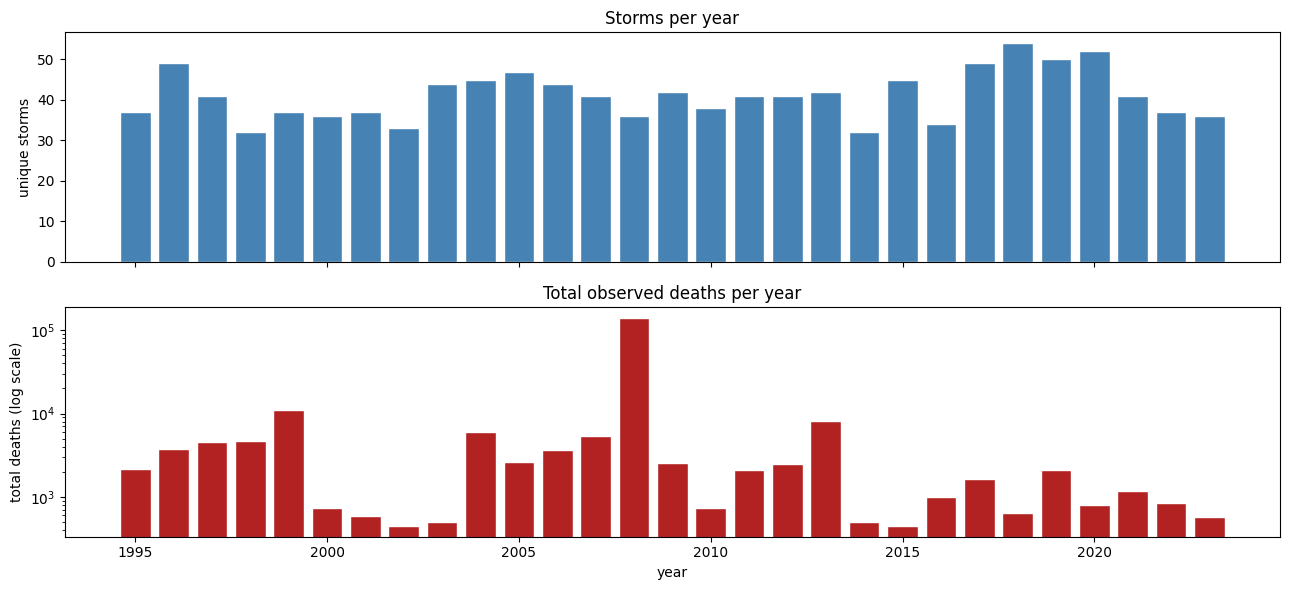

 year  n_storms  n_storm_admin_rows  total_deaths
 1995        37                  70          2141
 1996        49                  91          3699
 1997        41                  75          4554
 1998        32                  64          4619
 1999        37                  75         10991
 2000        36                  75           730
 2001        37                  67           596
 2002        33                  63           443
 2003        44                  69           504
 2004        45                 105          5976
 2005        47                  94          2643
 2006        44                  77          3619
 2007        41                  79          5395
 2008        36                  86        140500
 2009        42                  65          2581
 2010        38                  81           737
 2011        41                  78          2086
 2012        41                  79          2477
 2013        42                  71          8083


In [3]:
per_year = (obs
    .groupby('year', as_index=False)
    .agg(n_storms=('storm_id', 'nunique'),
         n_storm_admin_rows=('storm_id', 'size'),
         total_deaths=('deaths', 'sum'))
    .sort_values('year'))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].bar(per_year['year'], per_year['n_storms'], color='steelblue', edgecolor='white')
axes[0].set_ylabel('unique storms')
axes[0].set_title('Storms per year')

axes[1].bar(per_year['year'], per_year['total_deaths'].clip(lower=1),
            color='firebrick', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_ylabel('total deaths (log scale)')
axes[1].set_xlabel('year')
axes[1].set_title('Total observed deaths per year')

plt.tight_layout()
plt.show()

print(per_year.to_string(index=False))


### Death concentration across storms

How concentrated is total mortality in the top few storms? This is the key
question for deciding whether the `full_pred_obs_ratio_oos` gate is being
dominated by a handful of mega-events, and for choosing N in
`drop top N storms before recomputing ratio` screens.


Top 20 storms by observed deaths:
     storm_id  year basin  total_deaths   pct  cum_pct
2008117N11090  2008    NI        138366 65.25    65.25
1999298N12099  1999    NI          9843  4.64    69.90
2013306N07162  2013    WP          7375  3.48    73.37
2007314N10093  2007    NI          4234  2.00    75.37
1997298N06140  1997    WP          3707  1.75    77.12
1998152N11075  1998    NI          2871  1.35    78.47
2004258N16300  2004    NA          2837  1.34    79.81
2012331N03157  2012    WP          1926  0.91    80.72
2005236N23285  2005    NA          1833  0.86    81.58
2004333N06154  2004    WP          1630  0.77    82.35
2006329N06150  2006    WP          1494  0.70    83.06
2011346N03156  2011    WP          1439  0.68    83.74
2019063S18038  2019    SI          1234  0.58    84.32
1995294N05163  1995    WP          1044  0.49    84.81
2017333N06082  2017    NI           911  0.43    85.24
2009270N10148  2009    WP           821  0.39    85.63
2006188N10143  2006    WP      

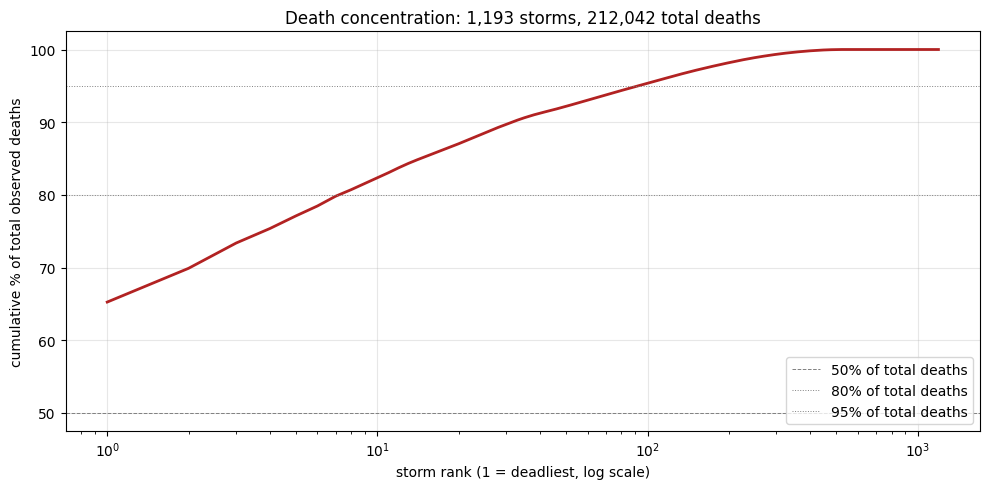


  Top   1 storms:  65.3% of all deaths
  Top   2 storms:  69.9% of all deaths
  Top   3 storms:  73.4% of all deaths
  Top   5 storms:  77.1% of all deaths
  Top  10 storms:  82.4% of all deaths
  Top  20 storms:  87.0% of all deaths
  Top  50 storms:  92.2% of all deaths
  Top 100 storms:  95.4% of all deaths


In [4]:
per_storm = (obs
    .groupby('storm_id', as_index=False)
    .agg(total_deaths=('deaths', 'sum'),
         year=('year', 'first'),
         basin=('basin', 'first'))
    .sort_values('total_deaths', ascending=False)
    .reset_index(drop=True))

total_deaths = per_storm['total_deaths'].sum()
n_storms     = len(per_storm)

# Top 20 storms with their share + cumulative share.
top20 = per_storm.head(20).copy()
top20['pct']     = (top20['total_deaths'] / total_deaths * 100).round(2)
top20['cum_pct'] = (top20['total_deaths'].cumsum() / total_deaths * 100).round(2)
print('Top 20 storms by observed deaths:')
print(top20[['storm_id', 'year', 'basin', 'total_deaths', 'pct', 'cum_pct']].to_string(index=False))

# Cumulative share curve — death concentration across storms.
fig, ax = plt.subplots(figsize=(10, 5))
cum_share = per_storm['total_deaths'].cumsum() / total_deaths * 100
ax.plot(np.arange(1, n_storms + 1), cum_share, color='firebrick', linewidth=2)
for h, style in [(50, '--'), (80, ':'), (95, ':')]:
    ax.axhline(h, color='gray', linestyle=style, linewidth=0.7,
               label=f'{h}% of total deaths')
ax.set_xscale('log')
ax.set_xlabel('storm rank (1 = deadliest, log scale)')
ax.set_ylabel('cumulative % of total observed deaths')
ax.set_title(f'Death concentration: {n_storms:,} storms, {int(total_deaths):,} total deaths')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Concrete cumulative shares — these inform the drop-top-N choice.
print()
for n in [1, 2, 3, 5, 10, 20, 50, 100]:
    if n <= n_storms:
        share = per_storm['total_deaths'].iloc[:n].sum() / total_deaths * 100
        print(f'  Top {n:>3} storms: {share:5.1f}% of all deaths')


**Read this section before judging the screening metrics:**

- A high concentration (top 5 storms ≥ 80% of deaths) means `full_pred_obs_ratio_oos`
  is effectively a function of how well the model handles those 5 storms — not
  a general calibration metric. The `[0.9, 1.1]` gate is then primarily a
  "did the model get Nargis right" filter.
- The same concentration justifies the `drop-top-N storms` variant of the
  screening ratio: if we want a metric sensitive to bulk-of-storms behaviour,
  we have to remove the events the aggregate is dominated by.
- For the time-series metrics: years dominated by mega-events drive the OLS
  regression. A correlation of 0.18 may be a Nargis/Haiyan artifact, not a
  model property — same drop-top-N logic applies (drop top-N years before
  computing `cor_ts_oos`).


## Setup

Load the evaluate run, median-aggregate IS and OOS metrics per
configuration, apply the calibration gate
(`full_pred_obs_ratio_oos ∈ [0.9, 1.1]`), and initialise the cumulative
screening mask. `df` holds the calibrated DH configs; `df_all` keeps
the pre-filter set for reference.

In [5]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
RESULTS_DIR = '20260714_v1995_refit'   # 02-evaluate (in-memory re-fit, 360 tasks)
RESULTS_PATH = ROOT / '02-evaluate' / RESULTS_DIR / 'dh_results.parquet'
print(RESULTS_PATH)

df_all = H.load_and_aggregate(RESULTS_PATH)
print(f'{len(df_all):,} configurations loaded across '
      f'{df_all["threshold_quantile"].nunique()} thresholds')

/mnt/team/idd/pub/idd_tc_mortality/02-evaluate/20260714_v1995_refit/dh_results.parquet
163,840 configurations loaded across 6 thresholds


In [6]:
# Calibration gate: Because tail storms are rare, we expect to under-predict total deaths.
# Culling models that are WAY too low or too high

RATIO_BOUNDS = (0.05, 1.1)
ratio      = df_all['full_pred_obs_ratio_oos']
calibrated = ratio.between(*RATIO_BOUNDS) & ratio.notna()
df = df_all[calibrated].reset_index(drop=True)
print(f'{len(df):,} configs ({len(df)/len(df_all):.1%}) pass '
      f'full_pred_obs_ratio_oos in [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]')

60,760 configs (37.1%) pass full_pred_obs_ratio_oos in [0.05, 1.1]


In [7]:
# Cumulative screening mask: True = config still in consideration.
screen = pd.Series(True, index=df.index)

def remaining(label: str) -> None:
    n = int(screen.sum())
    per_thr = df.loc[screen, 'threshold_quantile'].value_counts().sort_index()
    print(f'{label}: {n:,} configs '
          f'({per_thr.to_dict()})')

remaining('Start')

Start: 60,760 configs ({0.7: 15026, 0.75: 13840, 0.7999999999999999: 11411, 0.85: 8734, 0.8999999999999999: 5434, 0.95: 6315})


## S1 — P(deaths >= 1)

S1 is threshold-independent: the binary outcome `any_death` does not
shift with `threshold_quantile`, so the same `(s1_family, s1_exposure_mode,
s1_cov)` triple yields identical S1 metrics across every DH config that
uses it. Deduplicate to one row per triple before plotting.

In [8]:
remaining('S1 start')

S1 start: 60,760 configs ({0.7: 15026, 0.75: 13840, 0.7999999999999999: 11411, 0.85: 8734, 0.8999999999999999: 5434, 0.95: 6315})


15 unique S1 specs


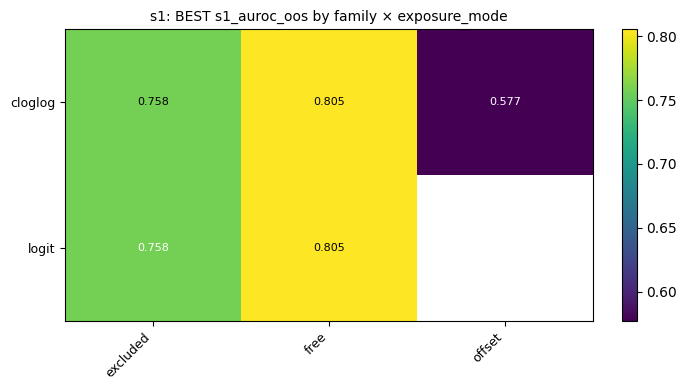

In [9]:
s1_df = H.dedup_for_stage(df, 's1')
print(f'{len(s1_df):,} unique S1 specs')

H.plot_stage_heatmap(s1_df, 's1', 's1_auroc_oos',
                     lower_better=False, log_scale=False,
                     facet_by_threshold=False)
plt.show()

In [10]:
# Numeric: best s1_auroc_oos per (family × exposure_mode).
print(H._family_exposure_pivot(s1_df, 's1', 's1_auroc_oos',
                                lower_better=False).round(4))

s1_exposure_mode  excluded    free  offset
s1_family                                 
cloglog             0.7576  0.8052  0.5773
logit               0.7575  0.8053     NaN


**Decision — S1.** Keep `s1_family = logit` and `s1_exposure_mode = free`.
`cloglog` ties `logit` to within ~0.001 AUROC, `excluded` drops to 0.72,
`offset` collapses to 0.58. Drop `cloglog`, `excluded`, and `offset`.

In [11]:
s1_keep = (df['s1_family'] == 'logit') & (df['s1_exposure_mode'] == 'free')
screen &= s1_keep
remaining('S1 end')

S1 end: 11,967 configs ({0.7: 2865, 0.75: 2781, 0.7999999999999999: 2225, 0.85: 1705, 0.8999999999999999: 1059, 0.95: 1332})


## S2 — P(rate >= threshold | deaths >= 1)

S2's binary outcome shifts with threshold, so dedup per
`(s2_family, s2_exposure_mode, s2_cov, threshold_quantile)` and facet by
threshold. The S2 plane is independent of the S1 / bulk / tail specs,
so the heatmap is the same regardless of the prior screening; the model
count, however, is cumulative.

In [12]:
remaining('S2 start')

S2 start: 11,967 configs ({0.7: 2865, 0.75: 2781, 0.7999999999999999: 2225, 0.85: 1705, 0.8999999999999999: 1059, 0.95: 1332})


60 unique (S2 spec × threshold) combinations


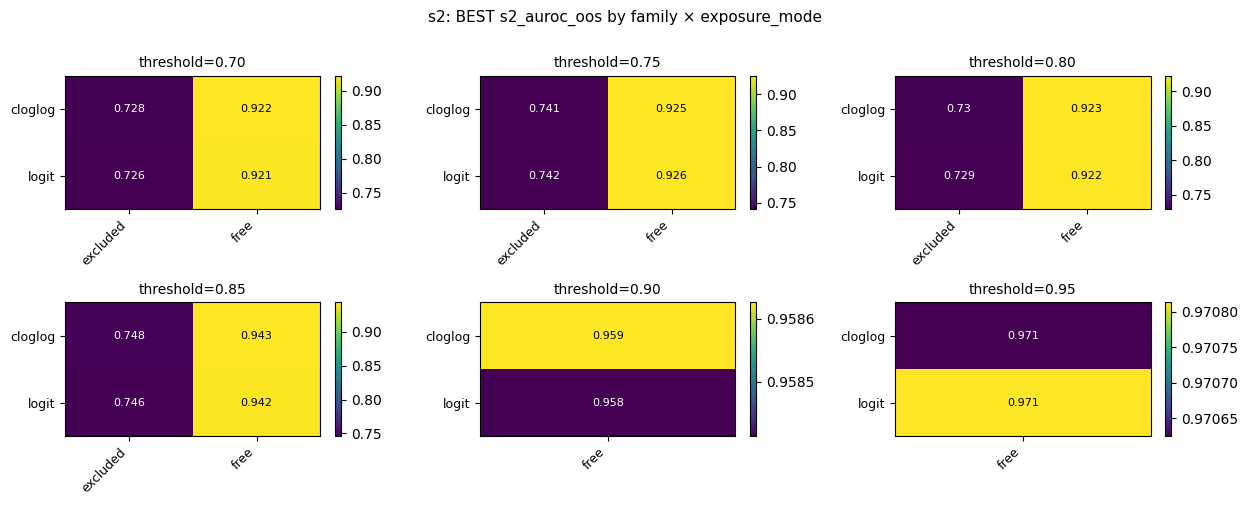

In [13]:
s2_df = H.dedup_for_stage(df, 's2')
print(f'{len(s2_df):,} unique (S2 spec × threshold) combinations')

H.plot_stage_heatmap(s2_df, 's2', 's2_auroc_oos',
                     lower_better=False, log_scale=False,
                     facet_by_threshold=True)
plt.show()

In [14]:
# Numeric: best s2_auroc_oos per (family × exposure_mode) per threshold.
for thr in sorted(s2_df['threshold_quantile'].dropna().unique()):
    chunk = s2_df[s2_df['threshold_quantile'] == thr]
    print(f'--- threshold={thr:.2f} ---')
    print(H._family_exposure_pivot(chunk, 's2', 's2_auroc_oos',
                                    lower_better=False).round(4))
    print()

--- threshold=0.70 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7278  0.9224
logit               0.7264  0.9211

--- threshold=0.75 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7414  0.9254
logit               0.7418  0.9258

--- threshold=0.80 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7303  0.9228
logit               0.7291  0.9225

--- threshold=0.85 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7480  0.9432
logit               0.7463  0.9417

--- threshold=0.90 ---
s2_exposure_mode    free
s2_family               
cloglog           0.9586
logit             0.9584

--- threshold=0.95 ---
s2_exposure_mode    free
s2_family               
cloglog           0.9706
logit             0.9708



**Decision — S2.** Keep `s2_family = logit` and `s2_exposure_mode = free`
at every threshold. `logit` and `cloglog` agree within ~0.001 AUROC in
every comparable cell; `free` dominates `excluded` by 0.10–0.15 AUROC,
widening at higher thresholds. Drop `cloglog` and `excluded`.

In [15]:
s2_keep = (df['s2_family'] == 'logit') & (df['s2_exposure_mode'] == 'free')
screen &= s2_keep
remaining('S2 end')

S2 end: 5,366 configs ({0.7: 1098, 0.75: 1144, 0.7999999999999999: 1010, 0.85: 855, 0.8999999999999999: 568, 0.95: 691})


## Bulk — E[rate | deaths >= 1, rate < threshold]

Bulk is doubly threshold-dependent: training set and eval set both
shift with threshold, so absolute-error metrics (`mae_rate`, `rmse_rate`,
`mae_count`) are *not* comparable across threshold columns of the same
panel. Read within a panel; use ranks / Kendall τ for cross-threshold
stability checks.

### Family choice

In [16]:
remaining('Bulk start')

Bulk start: 5,366 configs ({0.7: 1098, 0.75: 1144, 0.7999999999999999: 1010, 0.85: 855, 0.8999999999999999: 568, 0.95: 691})


299 unique (bulk spec × threshold) combinations


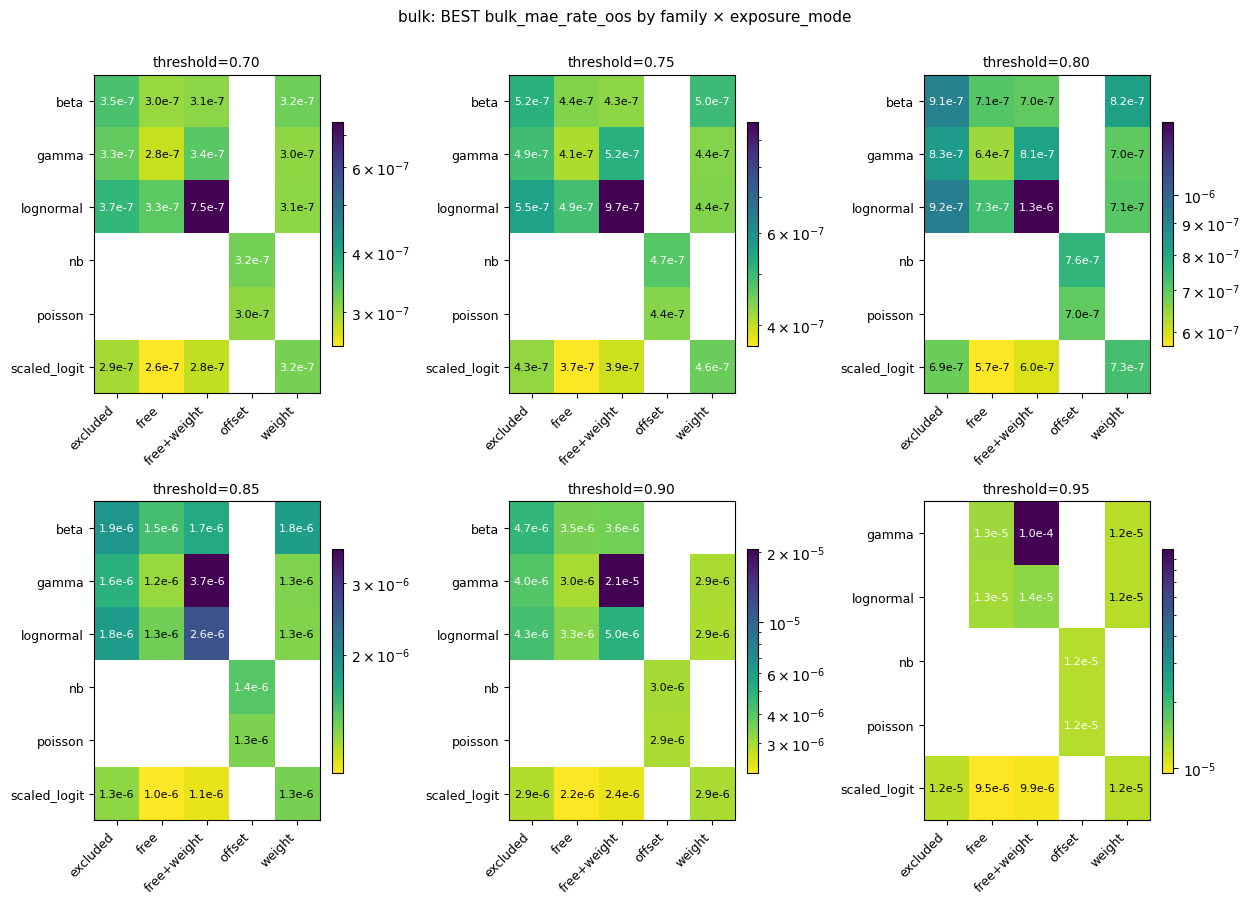

In [17]:
bulk_df = H.dedup_for_stage(df, 'bulk')
print(f'{len(bulk_df):,} unique (bulk spec × threshold) combinations')

H.plot_stage_heatmap(bulk_df, 'bulk', 'bulk_mae_rate_oos',
                     lower_better=True, log_scale=True,
                     facet_by_threshold=True)
plt.show()

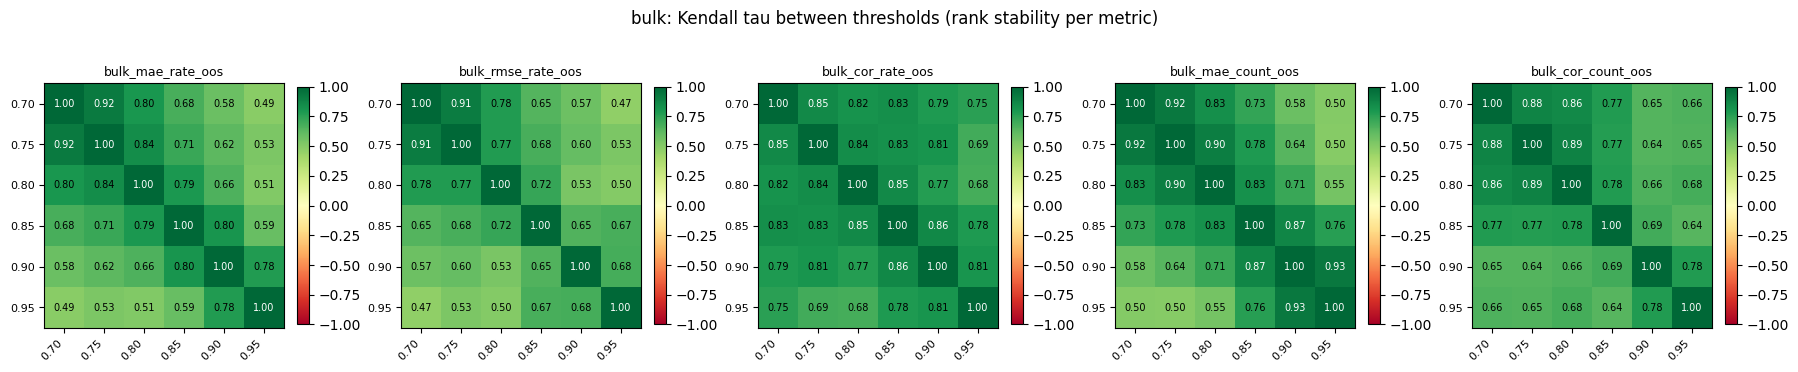

In [18]:
# Cross-threshold rank stability: high τ → family decision transfers across thresholds.
BULK_METRICS = [
    'bulk_mae_rate_oos', 'bulk_rmse_rate_oos', 'bulk_cor_rate_oos',
    'bulk_mae_count_oos', 'bulk_cor_count_oos',
]
BULK_DIR = {
    'bulk_mae_rate_oos':  'lower',
    'bulk_rmse_rate_oos': 'lower',
    'bulk_cor_rate_oos':  'higher',
    'bulk_mae_count_oos': 'lower',
    'bulk_cor_count_oos': 'higher',
}
H.kendall_threshold_heatmap(bulk_df, 'bulk', BULK_METRICS,
                            metric_directions=BULK_DIR)
plt.show()

**Decision — Bulk family.** Keep `bulk_family = scaled_logit` —
both enforce `predicted_rate ∈ (0, threshold)` by construction. Drop
`gamma`, `lognormal`, `nb`, `poisson`, `beta`. 

In [19]:
bulk_fam_keep = df['bulk_family'].isin(['scaled_logit'])
screen &= bulk_fam_keep
remaining('Bulk after family decision')

Bulk after family decision: 1,377 configs ({0.7: 250, 0.75: 256, 0.7999999999999999: 232, 0.85: 215, 0.8999999999999999: 185, 0.95: 239})


### Exposure mode

With family narrowed to `scaled_logit`, re-examine the
`exposure_mode` plane.

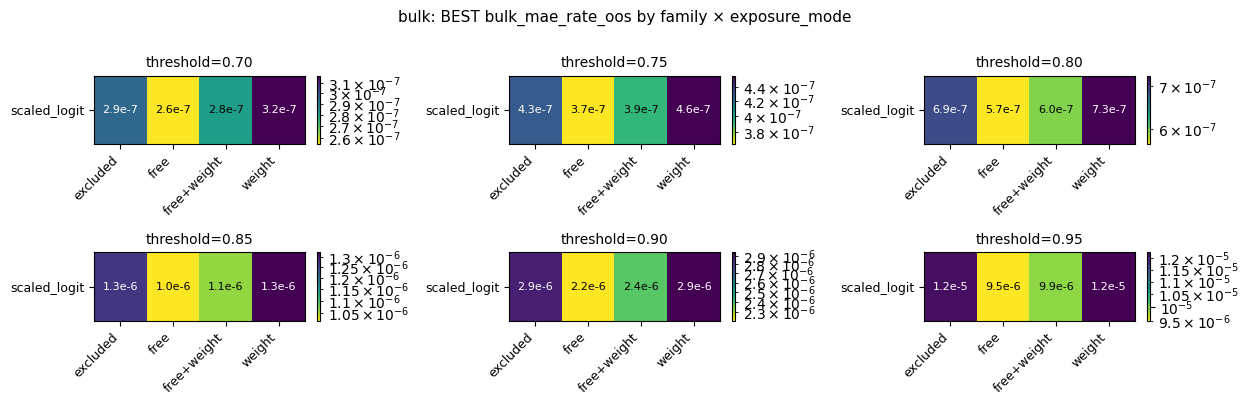

In [20]:
bulk_focus_df = bulk_df[bulk_df['bulk_family'].isin(['scaled_logit'])].copy()
H.plot_stage_heatmap(bulk_focus_df, 'bulk', 'bulk_mae_rate_oos',
                     lower_better=True, log_scale=True,
                     facet_by_threshold=True)
plt.show()

**Decision — Bulk exposure mode.** Keep `bulk_exposure_mode ∈ {free,
free+weight}` for both surviving families. Drop `excluded` and `weight`.
The choice between `free` and `free+weight` is a downstream calibration
question, not a screening one.

In [21]:
bulk_exp_keep = df['bulk_exposure_mode'].isin(['free', 'free+weight'])
screen &= bulk_exp_keep
remaining('Bulk end')

Bulk end: 692 configs ({0.7: 126, 0.75: 128, 0.7999999999999999: 116, 0.85: 108, 0.8999999999999999: 94, 0.95: 120})


## Tail — E[rate | deaths >= 1, rate >= threshold]

Tail has more families and noisier cross-threshold rankings than bulk
(adjacent-threshold Kendall τ around 0.4–0.5 in count metrics). The
cleanest screening question is therefore *attainability*: which
families have at least one (cov × exposure_mode) combination that
reaches the top of the rankings at each (metric × threshold) cell?

In [22]:
remaining('Tail start')

Tail start: 692 configs ({0.7: 126, 0.75: 128, 0.7999999999999999: 116, 0.85: 108, 0.8999999999999999: 94, 0.95: 120})


357 unique (tail spec × threshold) combinations


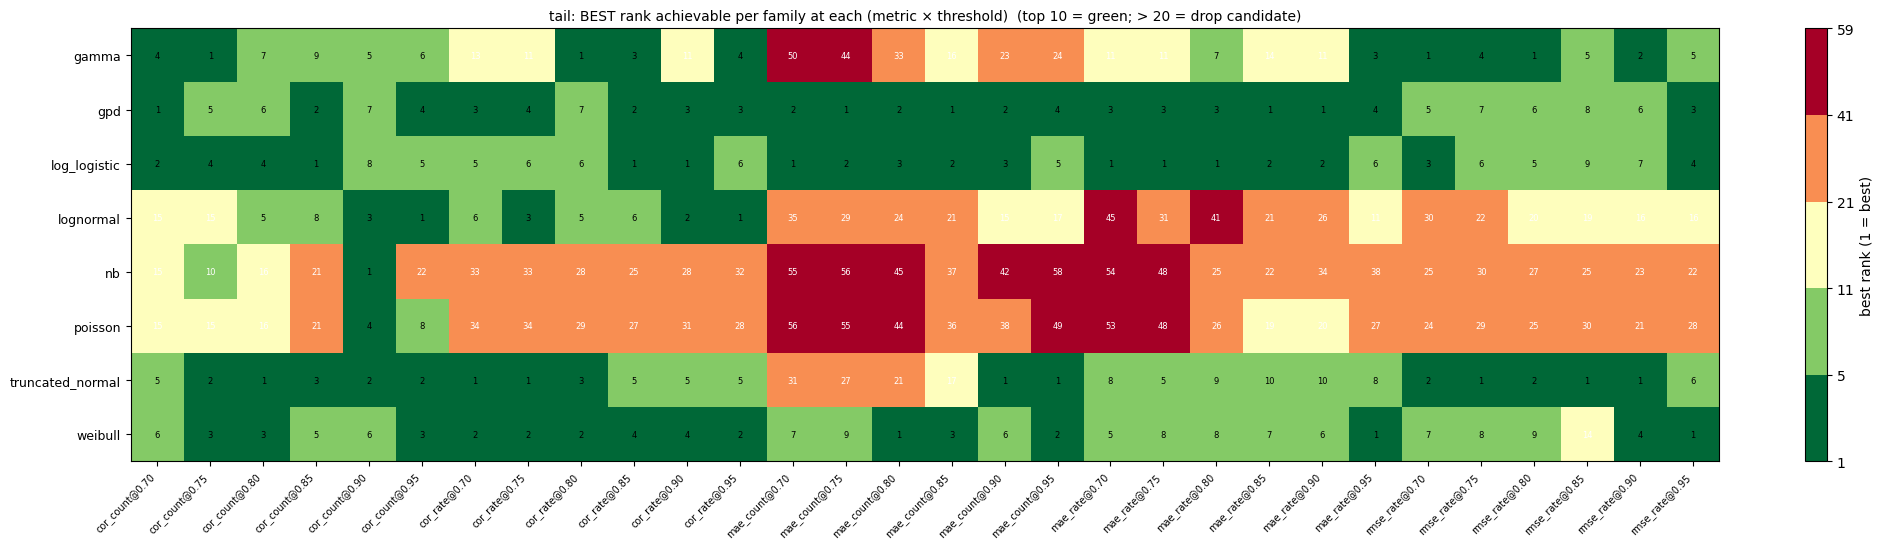

In [23]:
tail_df = H.dedup_for_stage(df, 'tail')
print(f'{len(tail_df):,} unique (tail spec × threshold) combinations')

TAIL_METRICS = [
    'tail_mae_rate_oos', 'tail_rmse_rate_oos', 'tail_cor_rate_oos',
    'tail_mae_count_oos', 'tail_cor_count_oos',
]
TAIL_DIR = {
    'tail_mae_rate_oos':  'lower',
    'tail_rmse_rate_oos': 'lower',
    'tail_cor_rate_oos':  'higher',
    'tail_mae_count_oos': 'lower',
    'tail_cor_count_oos': 'higher',
}
H.family_attainability_heatmap(tail_df, 'tail', TAIL_METRICS,
                               metric_directions=TAIL_DIR,
                               top_n=10, drop_threshold=20)
plt.show()

**Decision — Tail.** Drop `nb` and `poisson` — best-rank-achievable is
> 20 in nearly every cell, and structurally they have no threshold
awareness. Keep `gpd`, `log_logistic`, `lognormal`, `truncated_normal`,
`gamma`, `weibull`. `gamma` and `weibull` are kept but **flagged as
suspicious** (gamma rank-2 on rate metrics at low thresholds but 32–45
in MAE-count cells; weibull never breaks top 10 in some cells).

In [24]:
tail_keep = ~df['tail_family'].isin(['nb', 'poisson'])
screen &= tail_keep
remaining('Tail end')

Tail end: 638 configs ({0.7: 118, 0.75: 120, 0.7999999999999999: 108, 0.85: 98, 0.8999999999999999: 84, 0.95: 110})


---

## Preliminary screening complete

The surviving family/exposure pool is the input to the next stage:
`notebooks/dh_intermediate_diagnostics_post2000.ipynb`, which loads the
per-row predictions for these survivors from `02-evaluate/20260517_survivors/`
and applies storm-level + per-year diagnostics (trimmed calibration
ratios, per-storm scatter, year-aggregate curves) that the preliminary
metric set could not.

The **Threshold decision is deferred** to the intermediate notebook —
with per-storm predictions in hand we can pick thresholds based on the
behaviour we actually care about (per-storm calibration on the bulk-of-
storms, not the Nargis-dominated aggregate).

The time-series horror-spot section below stays as a sanity check on
the surviving pool.


## Time-series calibration — `cor_ts`, `beta_0_ts`, `beta_p_ts`

The aggregate `full_pred_obs_ratio_oos` gate averages over storms, locations, AND
years. A model can have ratio ≈ 1.0 globally and still be badly miscalibrated in
specific years. The three new metrics catch that:

- **`cor_ts_oos`** — Pearson correlation between yearly Σ observed deaths and
  yearly Σ predicted deaths across the data window.
- **`beta_0_ts_oos`** — OLS intercept of `obs_y ~ beta_0 + beta_p * pred_y`.
- **`beta_p_ts_oos`** — OLS slope of the same.

Ideal calibration is `cor_ts_oos = 1`, `beta_0_ts_oos = 0`, `beta_p_ts_oos = 1`.
A near-1 correlation with `beta_p_ts_oos = 2` is a 2× systematic underprediction
across years — the kind of failure mode the aggregate gate is silent on.

This section is a **horror-spot, not a screen** (yet). It shows the distribution
across calibrated configs and a visual of how close to ideal the surviving
configs are. Bobby decides whether to add a screening gate (e.g., require
`cor_ts_oos >= 0.5` and `beta_p_ts_oos ∈ [0.5, 2.0]`) after looking at the
distribution.


In [25]:
# Quick sanity: are the new columns present?
ts_cols = ['cor_ts', 'beta_0_ts', 'beta_p_ts',
           'cor_ts_oos', 'beta_0_ts_oos', 'beta_p_ts_oos']
present = [c for c in ts_cols if c in df.columns]
missing = [c for c in ts_cols if c not in df.columns]
print('present:', present)
print('missing:', missing)

# Summary stats across calibrated configs (OOS is the screening-relevant view).
print()
print('Distribution across', len(df), 'calibrated configs:')
print(df[['cor_ts_oos', 'beta_0_ts_oos', 'beta_p_ts_oos']]
      .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
      .round(4))


present: ['cor_ts', 'beta_0_ts', 'beta_p_ts', 'cor_ts_oos', 'beta_0_ts_oos', 'beta_p_ts_oos']
missing: []

Distribution across 60760 calibrated configs:
       cor_ts_oos  beta_0_ts_oos  beta_p_ts_oos
count  60760.0000     60760.0000     60760.0000
mean       0.2206    -12547.1786         7.7382
std        0.0931      9694.2550         7.7324
min       -0.1716    -48747.3303        -3.0905
5%         0.0290    -26082.3047         0.4006
25%        0.1827    -19848.6822         2.9916
50%        0.2377    -13184.7672         5.3663
75%        0.2822     -6546.0894         9.5747
95%        0.3414      5552.6715        23.9819
max        0.4567     16332.3878        67.3394


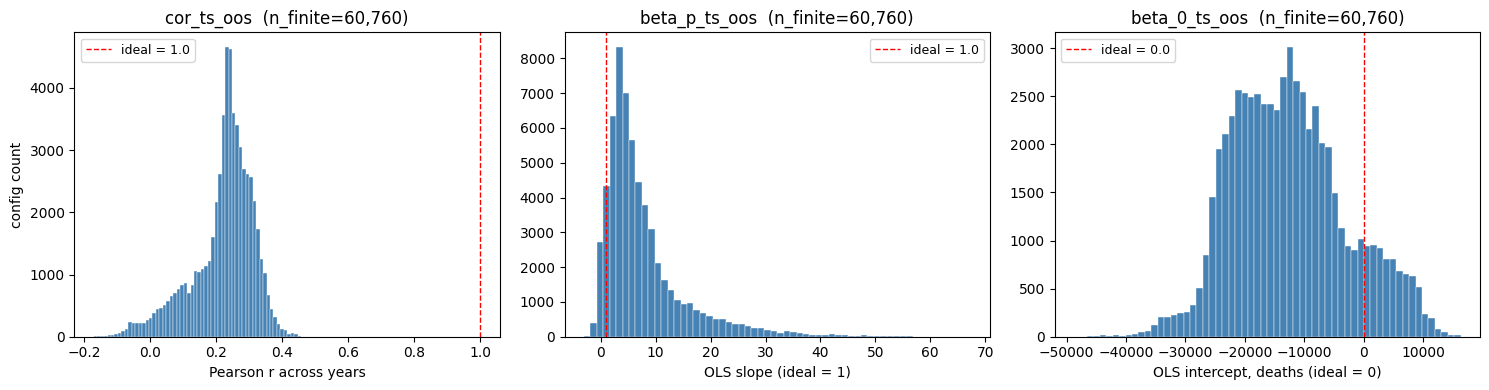

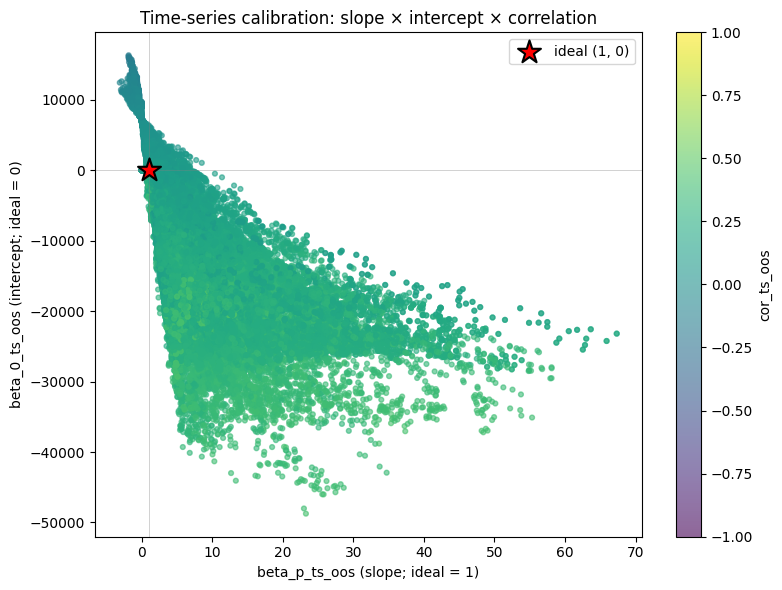

In [26]:
# Three-panel histogram of the OOS time-series metrics.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

panels = [
    ('cor_ts_oos',    1.0, 'Pearson r across years',          axes[0]),
    ('beta_p_ts_oos', 1.0, 'OLS slope (ideal = 1)',            axes[1]),
    ('beta_0_ts_oos', 0.0, 'OLS intercept, deaths (ideal = 0)', axes[2]),
]
for col, ideal, title, ax in panels:
    vals = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(ideal, color='red', linestyle='--', linewidth=1, label=f'ideal = {ideal}')
    ax.set_title(f'{col}  (n_finite={len(vals):,})')
    ax.set_xlabel(title)
    ax.legend(loc='best', fontsize=9)
axes[0].set_ylabel('config count')
plt.tight_layout()
plt.show()

# Slope vs intercept, colored by correlation. Ideal point is (1, 0)
# with bright color (high correlation).
fig, ax = plt.subplots(figsize=(8, 6))
finite = df[['beta_p_ts_oos', 'beta_0_ts_oos', 'cor_ts_oos']].replace(
    [np.inf, -np.inf], np.nan).dropna()
sc = ax.scatter(finite['beta_p_ts_oos'], finite['beta_0_ts_oos'],
                c=finite['cor_ts_oos'].clip(-1, 1),
                cmap='viridis', s=12, alpha=0.6, vmin=-1, vmax=1)
ax.scatter([1.0], [0.0], color='red', marker='*', s=300,
           edgecolor='black', linewidth=1.5, zorder=10, label='ideal (1, 0)')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(1, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel('beta_p_ts_oos (slope; ideal = 1)')
ax.set_ylabel('beta_0_ts_oos (intercept; ideal = 0)')
ax.set_title('Time-series calibration: slope × intercept × correlation')
plt.colorbar(sc, ax=ax, label='cor_ts_oos')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


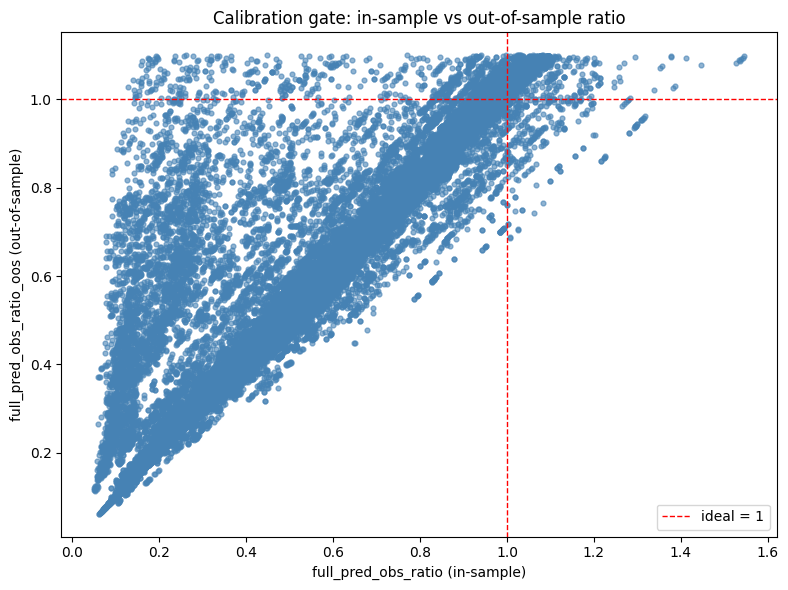

In [27]:
# Scatter plot in sample ratio against OOS ratio
fig, ax = plt.subplots(figsize=(8, 6))
finite = df[['full_pred_obs_ratio', 'full_pred_obs_ratio_oos']].replace(
    [np.inf, -np.inf], np.nan).dropna()
ax.scatter(finite['full_pred_obs_ratio'], finite['full_pred_obs_ratio_oos'],
           color='steelblue', alpha=0.6, s=12)
ax.axhline(1, color='red', linestyle='--', linewidth=1, label='ideal = 1')
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('full_pred_obs_ratio (in-sample)')
ax.set_ylabel('full_pred_obs_ratio_oos (out-of-sample)')
ax.set_title('Calibration gate: in-sample vs out-of-sample ratio')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

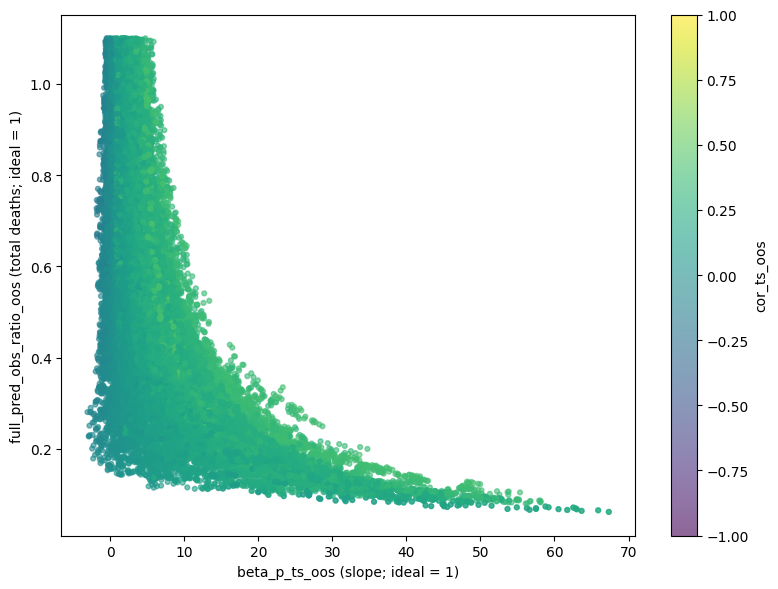

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
finite = df[['beta_p_ts_oos', 'beta_0_ts_oos', 'cor_ts_oos', 'full_pred_obs_ratio_oos']].replace(
    [np.inf, -np.inf], np.nan).dropna()
sc = ax.scatter(finite['beta_p_ts_oos'], finite['full_pred_obs_ratio_oos'],
                c=finite['cor_ts_oos'].clip(-1, 1),
                cmap='viridis', s=12, alpha=0.6, vmin=-1, vmax=1)
ax.set_xlabel('beta_p_ts_oos (slope; ideal = 1)')
ax.set_ylabel('full_pred_obs_ratio_oos (total deaths; ideal = 1)')
plt.colorbar(sc, ax=ax, label='cor_ts_oos')
plt.tight_layout()
plt.show()

**What to look for:**

- A tight cluster around the red star = many configs are well-calibrated in time.
  Loose cluster = the aggregate gate is letting through configs with bad
  year-level calibration.
- High `cor_ts_oos` with `beta_p_ts_oos` far from 1 = perfect *shape* match
  across years, but systematic scale bias. The aggregate gate misses this.
- Long left tail in `cor_ts_oos` = configs whose year totals are negatively
  correlated with observed — a strong skip signal.

**No screen applied yet.** Move to the per-stage sections below for the
existing decisions.
